# Análisis exploratorio de una base de datos de películas

Usa la base de datos `./data/imdb.csv`


### 1. Importar `pandas`, `matplotlib` y `numpy`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### 2. Leer la base de datos del archivo csv a pandas

In [2]:
df = pd.read_csv('./data/imdb.csv')

### 3. Mostrar las  primeras y últimas filas del dataframe. Hacerlo con el valor default y pasando como argumento el número entero de filas que se deseen inspeccionar.

In [3]:
# Muestra las primeras 5 por default
display(df.head())

# Muestra las últimas 3 (pasando el argumento)
display(df.tail(3))

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
997,998,Step Up 2: The Streets,"Drama,Music,Romance",Romantic sparks occur between two dance studen...,Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.2,70699,58.01,50.0
998,999,Search Party,"Adventure,Comedy",A pair of friends embark on a mission to reuni...,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,5.6,4881,NaN,22.0
999,1000,Nine Lives,"Comedy,Family,Fantasy",A stuffy businessman finds himself trapped ins...,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.3,12435,19.64,11.0


### 4. Continúa inspeccionando el archivo viendo todas las columnas del dataframe

In [4]:
df.columns

Index(['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year',
       'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)',
       'Metascore'],
      dtype='str')

### 5. Imprime los primeros valores de la variable `Rank`

In [5]:
df['Rank'].head()

0    1
1    2
2    3
3    4
4    5
Name: Rank, dtype: int64

### 6. Demuestra que es mejor tener nombres de columnas sin espacios (notación corchetes y notación punto-variable).

In [6]:
# Con corchetes podemos llamar columnas con espacios sin problem
display(df['Revenue (Millions)'].head(2))
# Si intentáramos usar notación de punto (ej. df.Revenue (Millions)) 
# Python nos marcaría un error de sintaxis porque cree que "Millions" es otra variable.

0    333.13
1    126.46
Name: Revenue (Millions), dtype: float64

### 7. Renombra las columnas que tengan espacios

In [7]:
# Vamos a reemplazar los espacios por guiones bajos para que sea "amigable" como vimos en clase 
df.rename(columns={
    'Runtime (Minutes)': 'Runtime_Minutes', 
    'Revenue (Millions)': 'Revenue_Millions'
}, inplace=True)

# Imprimimos para verificar que ya no hay espacios
df.columns

Index(['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year',
       'Runtime_Minutes', 'Rating', 'Votes', 'Revenue_Millions', 'Metascore'],
      dtype='str')

### 8. Utiliza tus nuevas columnas sin espacios :)

In [8]:
# ¡Ahora sí podemos usar la notación de punto
df.Revenue_Millions.head()

0    333.13
1    126.46
2    138.12
3    270.32
4    325.02
Name: Revenue_Millions, dtype: float64

### 9. Visualiza la info de todo tu dataframe

In [9]:
# usamos la funcion info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              1000 non-null   int64  
 1   Title             1000 non-null   str    
 2   Genre             1000 non-null   str    
 3   Description       1000 non-null   str    
 4   Director          1000 non-null   str    
 5   Actors            1000 non-null   str    
 6   Year              1000 non-null   int64  
 7   Runtime_Minutes   1000 non-null   int64  
 8   Rating            1000 non-null   float64
 9   Votes             1000 non-null   int64  
 10  Revenue_Millions  872 non-null    float64
 11  Metascore         936 non-null    float64
dtypes: float64(3), int64(4), str(5)
memory usage: 93.9 KB


### 10. Inspecciona si hay columnas que tengan valores `NA`

In [11]:
# con isna obtenemos los valores NAN
df.isna().sum()

Rank                  0
Title                 0
Genre                 0
Description           0
Director              0
Actors                0
Year                  0
Runtime_Minutes       0
Rating                0
Votes                 0
Revenue_Millions    128
Metascore            64
dtype: int64

### 11. Imprime el número total de valores NA que haya en cada columna. Hazlo primero para la columna `Metascore` y después utiliza un ciclo for para hacerlo para todas las columnas

In [12]:
#  Primero solo para la columna Metascore
print("Nulos en Metascore:", df['Metascore'].isna().sum())

print("-" * 20) 

# Ahora usando un ciclo for para iterar por todas las columnas
for columna in df.columns:
    nulos = df[columna].isna().sum()
    print(f"{columna}: {nulos}")

Nulos en Metascore: 64
--------------------
Rank: 0
Title: 0
Genre: 0
Description: 0
Director: 0
Actors: 0
Year: 0
Runtime_Minutes: 0
Rating: 0
Votes: 0
Revenue_Millions: 128
Metascore: 64


### 12. Usa la magia de `dropna()`

In [13]:
# Eliminamos todas las filas que contengan algún valor nulo (NaN) de forma permanente
df.dropna(inplace=True)

### 13. Vuelve a ver la info del dataset

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 838 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              838 non-null    int64  
 1   Title             838 non-null    str    
 2   Genre             838 non-null    str    
 3   Description       838 non-null    str    
 4   Director          838 non-null    str    
 5   Actors            838 non-null    str    
 6   Year              838 non-null    int64  
 7   Runtime_Minutes   838 non-null    int64  
 8   Rating            838 non-null    float64
 9   Votes             838 non-null    int64  
 10  Revenue_Millions  838 non-null    float64
 11  Metascore         838 non-null    float64
dtypes: float64(3), int64(4), str(5)
memory usage: 85.1 KB


### 14. Genera estadísticos descriptivos con el método `describe()`

In [15]:
# nos da el conteo, promedio, mínimo, máximo y los cuartiles de todas las columnas numéricas de un golpe.
df.describe()

,Rank,Year,Runtime_Minutes,Rating,Votes,Revenue_Millions,Metascore
count,838.000000,838.00000,838.000000,838.000000,8.380000e+02,838.000000,838.000000
mean,485.247017,2012.50716,114.638425,6.814320,1.932303e+05,84.564558,59.575179
std,286.572065,3.17236,18.470922,0.877754,1.930990e+05,104.520227,16.952416
min,1.000000,2006.00000,66.000000,1.900000,1.780000e+02,0.000000,11.000000
25%,238.250000,2010.00000,101.000000,6.300000,6.127650e+04,13.967500,47.000000
50%,475.500000,2013.00000,112.000000,6.900000,1.368795e+05,48.150000,60.000000
75%,729.750000,2015.00000,124.000000,7.500000,2.710830e+05,116.800000,72.000000
max,1000.000000,2016.00000,187.000000,9.000000,1.791916e+06,936.630000,100.000000


### 15. Crea un histograma de la variable Metascore. Utiliza 10 cubetas

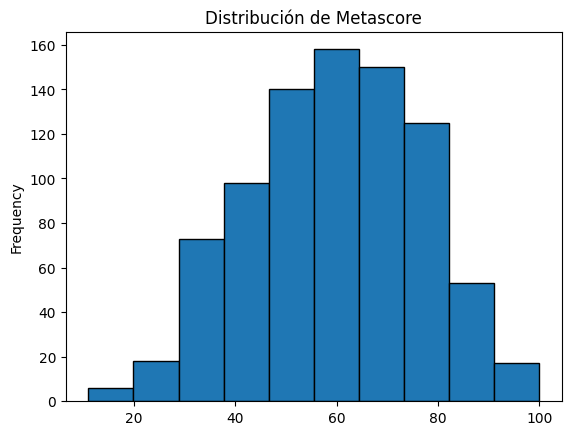

In [16]:
# Graficamos con 10 cubetas (bins) 
df['Metascore'].plot(kind='hist', bins=10, edgecolor='black')
plt.title('Distribución de Metascore')
plt.show()

### 16. Crea un histograma de la variable Rating. Utiliza 10 cubetas

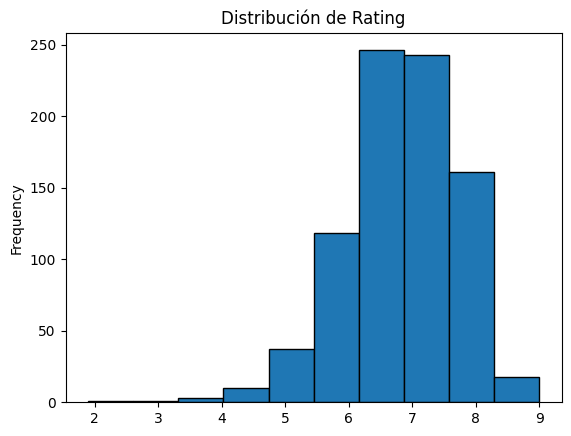

In [17]:
# hacemos lo mismo 
df['Rating'].plot(kind='hist', bins=10, edgecolor='black')
plt.title('Distribución de Rating')
plt.show()

### 17. Vuelve a describir el dataframe y observa la media de la variable `Ratings`

In [18]:
display(df.describe())
# la media anda en 6.81

,Rank,Year,Runtime_Minutes,Rating,Votes,Revenue_Millions,Metascore
count,838.000000,838.00000,838.000000,838.000000,8.380000e+02,838.000000,838.000000
mean,485.247017,2012.50716,114.638425,6.814320,1.932303e+05,84.564558,59.575179
std,286.572065,3.17236,18.470922,0.877754,1.930990e+05,104.520227,16.952416
min,1.000000,2006.00000,66.000000,1.900000,1.780000e+02,0.000000,11.000000
25%,238.250000,2010.00000,101.000000,6.300000,6.127650e+04,13.967500,47.000000
50%,475.500000,2013.00000,112.000000,6.900000,1.368795e+05,48.150000,60.000000
75%,729.750000,2015.00000,124.000000,7.500000,2.710830e+05,116.800000,72.000000
max,1000.000000,2016.00000,187.000000,9.000000,1.791916e+06,936.630000,100.000000


### 18. Calcula este promedio con Numpy y después con un método de Pandas

In [19]:
media_numpy = np.mean(df['Rating'])
media_pandas = df['Rating'].mean()

print(f"Media con Numpy: {media_numpy}")
print(f"Media con Pandas: {media_pandas}")

Media con Numpy: 6.814319809069212
Media con Pandas: 6.814319809069212


### 19. Obten los valores únicos de la variable Rating y después ordénalos de menor a mayor

In [20]:
#Sacamos qué calificaciones únicas existen y las ordenamos de menor a mayor
valores_unicos = df['Rating'].unique()
valores_ordenados = np.sort(valores_unicos)

print(valores_ordenados)

[1.9 2.7 3.9 4.  4.1 4.3 4.4 4.6 4.7 4.8 4.9 5.  5.1 5.2 5.3 5.4 5.5 5.6
 5.7 5.8 5.9 6.  6.1 6.2 6.3 6.4 6.5 6.6 6.7 6.8 6.9 7.  7.1 7.2 7.3 7.4
 7.5 7.6 7.7 7.8 7.9 8.  8.1 8.2 8.3 8.4 8.5 8.6 8.8 9. ]


### 20. Observa los ratings que te interesen y ahora filtra el dataframe con ese rating para ver cuáles son las películas con dicho rating

In [21]:
# yo usare la calificacion de 8.5 
mi_rating_favorito = 8.5
peliculas_filtradas = df[df['Rating'] == mi_rating_favorito]

display(peliculas_filtradas.head())

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime_Minutes,Rating,Votes,Revenue_Millions,Metascore
64,65,The Prestige,"Drama,Mystery,Sci-Fi",Two stage magicians engage in competitive one-...,Christopher Nolan,"Christian Bale, Hugh Jackman, Scarlett Johanss...",2006,130,8.5,913152,53.08,66.0
99,100,The Departed,"Crime,Drama,Thriller",An undercover cop and a mole in the police att...,Martin Scorsese,"Leonardo DiCaprio, Matt Damon, Jack Nicholson,...",2006,151,8.5,937414,132.37,85.0
124,125,The Dark Knight Rises,"Action,Thriller",Eight years after the Joker's reign of anarchy...,Christopher Nolan,"Christian Bale, Tom Hardy, Anne Hathaway,Gary ...",2012,164,8.5,1222645,448.13,78.0
133,134,Whiplash,"Drama,Music",A promising young drummer enrolls at a cut-thr...,Damien Chazelle,"Miles Teller, J.K. Simmons, Melissa Benoist, P...",2014,107,8.5,477276,13.09,88.0
476,477,The Lives of Others,"Drama,Thriller","In 1984 East Berlin, an agent of the secret po...",Florian Henckel von Donnersmarck,"Ulrich Mühe, Martina Gedeck,Sebastian Koch, Ul...",2006,137,8.5,278103,11.28,89.0


### 21. Obten los valores únicos de la variable Rating y la frecuencia total de cada uno de estos valores. Posteriormente crea un nuevo dataframe con essos valores

In [22]:
# El value_counts() hace todo el trabajo de contar y agrupar.
# Con reset_index() lo convertimos en un Dataframe nuevo y bonito.
df_ratings = df['Rating'].value_counts().reset_index()

# Le ponemos nombres claros a las columnas
df_ratings.columns = ['Rating', 'Frecuencia']

display(df_ratings.head())

,Rating,Frecuencia
0,7.0,43
1,6.7,42
2,7.1,40
3,7.2,38
4,7.8,38


### 22. Ordena el nuevo dataframe por la variable `rating`

In [23]:
# Ordenamos de mayor a menor
df_ratings_ordenado = df_ratings.sort_values(by='Rating')

display(df_ratings_ordenado.head())

,Rating,Frecuencia
46,1.9,1
47,2.7,1
39,3.9,2
45,4.0,1
42,4.1,1


### 23. Crea una gráfica de barras con este nuevo dataframe ordenado

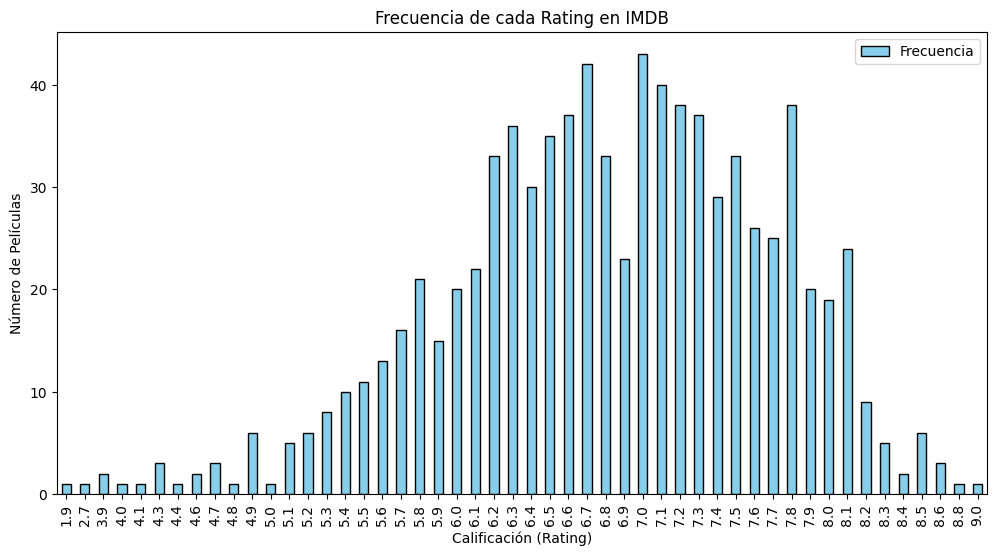

In [24]:
# Usamos el dataframe que ordenamos en el paso anterior (df_ratings_ordenado)
df_ratings_ordenado.plot(kind='bar', x='Rating', y='Frecuencia', figsize=(12,6), color='skyblue', edgecolor='black')
plt.title('Frecuencia de cada Rating en IMDB')
plt.xlabel('Calificación (Rating)')
plt.ylabel('Número de Películas')
plt.show()

### 24. Crea la matriz de correlación del dataframe de películas

In [25]:
corr = df.select_dtypes(include=[np.number]).corr()
display(corr)

,Rank,Year,Runtime_Minutes,Rating,Votes,Revenue_Millions,Metascore
Rank,1.000000,-0.312809,-0.254783,-0.243125,-0.303284,-0.273170,-0.195909
Year,-0.312809,1.000000,-0.101933,-0.145703,-0.362445,-0.129198,-0.062303
Runtime_Minutes,-0.254783,-0.101933,1.000000,0.374566,0.399298,0.281721,0.221397
Rating,-0.243125,-0.145703,0.374566,1.000000,0.517452,0.217106,0.672731
Votes,-0.303284,-0.362445,0.399298,0.517452,1.000000,0.636833,0.332674
Revenue_Millions,-0.273170,-0.129198,0.281721,0.217106,0.636833,1.000000,0.142397
Metascore,-0.195909,-0.062303,0.221397,0.672731,0.332674,0.142397,1.000000


### 25. Grafica la matriz de correlación utilizando `matshow()`

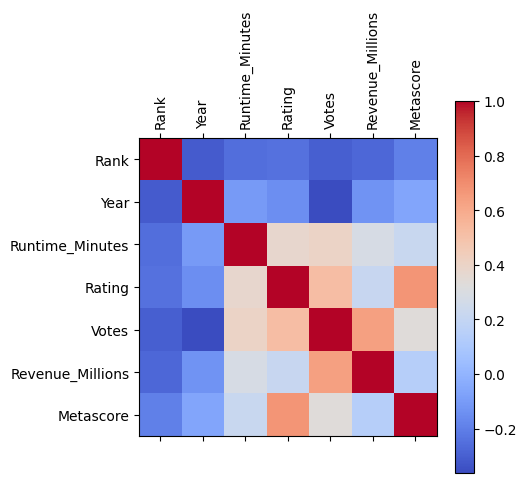

In [26]:
plt.matshow(corr, cmap='coolwarm')

# Añadimos los nombres de las columnas para poder leerla
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Añadimos una barra de color para saber qué tan fuerte es la relación
plt.colorbar()
plt.show()